In [1]:
import os
os.chdir("../")
configs_file = "train_cvit"

In [2]:
# import os
# from functools import partial

# import equinox as eqx
# import jax
# jax.config.update("jax_default_matmul_precision", "highest")
# # jax.config.update("jax_default_matmul_precision", "float32") 
# import jax.numpy as jnp
# import matplotlib.pyplot as plt
# from einops import rearrange, reduce, repeat

# from burgers.configs import load_configs
# configs = load_configs(configs_file)


# from ggsci import pal_npg, pal_gsea
# colors = pal_npg()(10)
# from matplotlib import font_manager
# font_dir = "./helvetica/"
# font_names = os.listdir(font_dir)
# for font_name in font_names:
#     font_manager.fontManager.addfont(font_dir + font_name)
# # nature style
# from matplotlib import rcParams
# rcParams.update({
#     "font.size": 7,
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Helvetica",],
#     "pdf.fonttype": 42,
#     "figure.dpi": 300,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     # thin ticks
#     "xtick.major.width": 0.5,
#     "ytick.major.width": 0.5,
#     # thin axes
#     "axes.linewidth": 0.5,
#     # thin legend frame
#     "legend.frameon": False,
#     # set color_theme as ggsci
#     "axes.prop_cycle": plt.cycler(color=[
#         "#E64B35", "#4DBBD5", "#00A087",
#         "#3C5488", "#F39B7F", "#8491B4",
#         "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
#     ]),
#     # "axes.prop_cycle": plt.cycler(color=colors),
# })

In [3]:
import numpy as np
import matplotlib.pyplot as plt

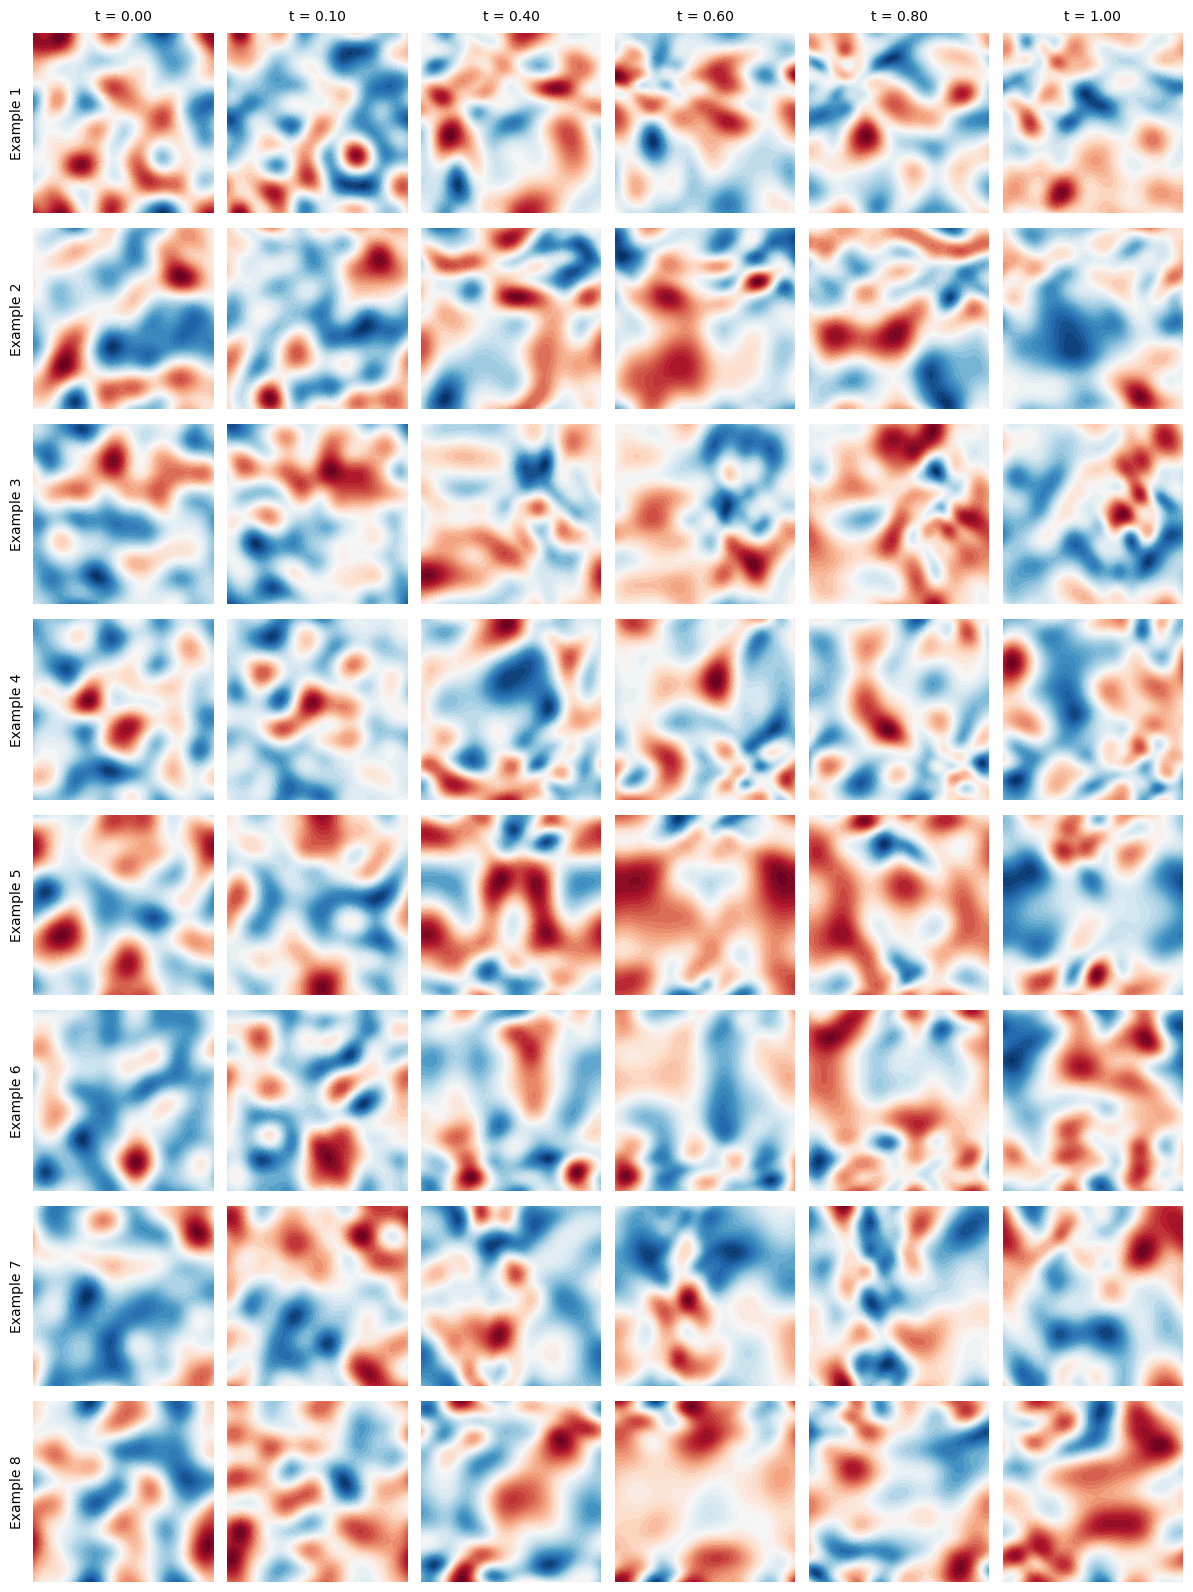

In [4]:
data = np.load("data/wave/wave_solutions.npz")
x = data["x"]
y = data["y"]
t = data["times"]
solutions = data["solutions"]  # (num_times, num_points)
xx, yy = np.meshgrid(x, y, indexing="xy") # (H, W)


time_idxs = [0, 1, 4, 6, 8, 10]
fig, axes = plt.subplots(8, 6, figsize=(12, 16), sharex=True, sharey=True)
for example_id in range(8):
    for i, time_idx in enumerate(time_idxs):
        ax = axes[example_id, i]
        ax.contourf(xx, yy, solutions[example_id, time_idx, 0], levels=50, cmap="RdBu_r")
        if example_id == 0:
            # ax.set_title(f"t = {t[time_idx]:.2f}", pad=5)
            ax.text(0.5, 1.05, f"t = {t[time_idx]:.2f}", va="bottom", ha="center", transform=ax.transAxes)
        if i == 0:
            # ax.set_ylabel(f"Example {example_id + 1}", rotation=0, labelpad=15)
            ax.text(-0.05, 0.5, f"Example {example_id + 1}", va="center", ha="right", rotation=90, transform=ax.transAxes)
        ax.set_axis_off()
        ax.set_aspect("equal")
fig.tight_layout()

In [5]:
data["times"]

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])